In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

In [2]:
counts_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/ccube_ultracleanveto_bestpsf_joined.fits")

In [3]:
cmap = 'RdBu_r'

In [5]:
pixel_size = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

In [6]:
upsample_factor = int(pixel_size_target / pixel_size)

In [7]:
np.logspace(np.log10(200), np.log10(2e9), 71)[i_e:i_e + 11] / 1e3

array([ 2000.        ,  2517.85082359,  3169.78638492,  3990.52462994,
        5023.77286302,  6324.55532034,  7962.14341107, 10023.74467255,
       12619.1468896 , 15886.56469449, 20000.        ])

In [8]:
counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

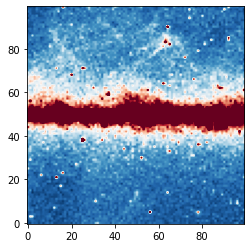

In [9]:
plt.imshow(counts_downsampled, vmax=100, cmap=cmap, origin='lower')